# CS 483 – Big Data Mining: FairLend Miners
## Task: Data Acquisition, Cleaning, and Binning Pipeline
**Author:** Archit Rathod  
**Dataset:** HMDA 2023 Snapshot National Loan-Level Dataset (CFPB)  
**Target MSA:** Chicago-Naperville-Elgin (16984)

---

This notebook performs the following:
1. **Data Acquisition** – Load the HMDA 2023 national file, filter to the Chicago MSA
2. **Data Cleaning** – Select relevant fields, handle missing values, decode coded fields
3. **Standard Binning** – Equal-frequency binning for income and loan amount
4. **Fair Binning** – ε-biased binning (inspired by Asudeh et al.) for the same attributes
5. **Export** – Save cleaned and binned datasets (standard + fair) to Google Drive as Parquet

## 0. Setup and Google Drive Mount

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os

# Create project directory on Google Drive
PROJECT_DIR = '/content/drive/MyDrive/CS483_FairLend'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f'Project directory: {PROJECT_DIR}')

Project directory: /content/drive/MyDrive/CS483_FairLend


In [ ]:
!pip install pyspark pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Initialize Spark (tuned for Colab T4: ~15GB RAM)
spark = SparkSession.builder \
    .appName('CS483_FairLend_DataPipeline') \
    .config('spark.driver.memory', '10g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

print(f'Spark version: {spark.version}')
print(f'Spark UI: {spark.sparkContext.uiWebUrl}')

Spark version: 4.0.2
Spark UI: http://f31c4696a802:4040


## 1. Data Acquisition

### Dataset - HMDA 2023 Snapshot:
1. Link to Data: https://ffiec.cfpb.gov/data-publication/snapshot-national-loan-level-dataset/2023
2. We use the **2023 Snapshot Loan/Application Records (LAR)** CSV file

In [ ]:
# ============================================================
# CONFIGURE THIS: Set the path to your downloaded HMDA CSV file
# ============================================================
# Option A: File is on Google Drive
HMDA_CSV_PATH = f'{PROJECT_DIR}/2023_public_lar_csv.zip'

# Option B: File is uploaded directly to Colab
# HMDA_CSV_PATH = '/content/2023_public_lar.csv'

assert os.path.exists(HMDA_CSV_PATH), \
    f'HMDA CSV not found at {HMDA_CSV_PATH}. Please download and place it there.'
print(f'Found HMDA file at: {HMDA_CSV_PATH}')
print(f'File size: {os.path.getsize(HMDA_CSV_PATH) / (1024**3):.2f} GB')

Found HMDA file at: /content/drive/MyDrive/CS483_FairLend/2023_public_lar_csv.zip
File size: 0.58 GB


In [ ]:
# Unzip the HMDA file (Spark cannot read zip directly)
import zipfile

ZIP_PATH = f'{PROJECT_DIR}/2023_public_lar_csv.zip'
CSV_PATH = f'{PROJECT_DIR}/2023_public_lar_csv.csv'

if not os.path.exists(CSV_PATH):
    print('Extracting zip file (this may take a few minutes)...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        # List contents to find the actual CSV name
        names = zf.namelist()
        print(f'Files in zip: {names}')
        csv_name = [n for n in names if n.endswith('.csv')][0]

        # Extract to project dir
        zf.extract(csv_name, PROJECT_DIR)
        extracted = os.path.join(PROJECT_DIR, csv_name)

        # Rename if needed
        if extracted != CSV_PATH:
            os.rename(extracted, CSV_PATH)

    print(f'Extracted to: {CSV_PATH}')
    print(f'CSV size: {os.path.getsize(CSV_PATH) / (1024**3):.2f} GB')
else:
    print(f'CSV already exists: {CSV_PATH}')
    print(f'CSV size: {os.path.getsize(CSV_PATH) / (1024**3):.2f} GB')

HMDA_CSV_PATH = CSV_PATH

CSV already exists: /content/drive/MyDrive/CS483_FairLend/2023_public_lar_csv.csv
CSV size: 4.04 GB


### 1.1 Load with Spark and Filter to Chicago MSA

Readint the full national file using Spark, then immediately filter to MSA 16980 (Chicago-Naperville-Elgin). This brings the dataset down to a manageable 200k rows.

In [ ]:
# Load the full HMDA CSV with Spark
raw_df = spark.read.csv(
    HMDA_CSV_PATH,
    header=True,
    inferSchema=False
)

print(f'Total columns in national file: {len(raw_df.columns)}')
print(f'Sample columns: {raw_df.columns[:10]}')
# Count is expensive on the full file; skip for now
# print(f'Total rows (national): {raw_df.count():,}')

Total columns in national file: 99
Sample columns: ['activity_year', 'lei', 'derived_msa_md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity']


In [ ]:
# Check what MSA values look like
print('Sample derived_msa_md values:')
raw_df.select('derived_msa_md').distinct().show(20, truncate=False)

# Check if Chicago appears with different formatting
print('\nValues containing "169":')
raw_df.filter(F.col('derived_msa_md').contains('169')).select('derived_msa_md').distinct().show(20, truncate=False)

# Also check for nulls and common values
print('\nTop 10 most common MSA values:')
raw_df.groupBy('derived_msa_md').count().orderBy(F.desc('count')).show(10, truncate=False)

Sample derived_msa_md values:
+--------------+
|derived_msa_md|
+--------------+
|31180         |
|12580         |
|17820         |
|40580         |
|45300         |
|38060         |
|24660         |
|21340         |
|15680         |
|25420         |
|31900         |
|27260         |
|22500         |
|42700         |
|32820         |
|48620         |
|15940         |
|19460         |
|45220         |
|35300         |
+--------------+
only showing top 20 rows

Values containing "169":
+--------------+
|derived_msa_md|
+--------------+
|16984         |
|16940         |
+--------------+


Top 10 most common MSA values:
+--------------+-------+
|derived_msa_md|count  |
+--------------+-------+
|99999         |1684742|
|12060         |275202 |
|26420         |238614 |
|38060         |208085 |
|16984         |204100 |
|19124         |200744 |
|31084         |188126 |
|35614         |169381 |
|47894         |166026 |
|45300         |158797 |
+--------------+-------+
only showing top 10 rows


In [ ]:
# Filter to Chicago-Naperville-Elgin MD (code 16984)
TARGET_MSA = '16984'

chicago_df = raw_df.filter(F.col('derived_msa_md') == TARGET_MSA)
chicago_count = chicago_df.count()
print(f'Rows in Chicago MSA ({TARGET_MSA}): {chicago_count:,}')

Rows in Chicago MSA (16984): 204,100


### 1.2 Select Relevant Columns

From the 90+ HMDA fields, we keep only those relevant to our fairness analysis:
- **Protected attributes:** race, sex, ethnicity
- **Financial features:** income, loan amount, debt-to-income ratio, interest rate
- **Loan characteristics:** loan type, loan purpose, property type, occupancy type
- **Outcome:** action_taken (our target: approved vs denied)
- **Geography:** county, census tract (for potential geographic analysis)

In [ ]:
# Columns to keep (matching actual HMDA 2023 Public LAR schema)
KEEP_COLS = [
    # Outcome
    'action_taken',

    # Protected attributes
    'derived_race',
    'derived_sex',
    'derived_ethnicity',
    'applicant_age',

    # Financial features
    'income',
    'loan_amount',
    'debt_to_income_ratio',
    'interest_rate',
    'combined_loan_to_value_ratio',
    'loan_term',

    # Loan characteristics
    'loan_type',
    'loan_purpose',
    'derived_dwelling_category',   # was 'property_type' (doesn't exist)
    'occupancy_type',
    'total_units',
    'lien_status',

    # Geography
    'derived_msa_md',
    'county_code',
    'census_tract',
]

# Verify all columns exist
available_cols = set(chicago_df.columns)
missing = [c for c in KEEP_COLS if c not in available_cols]
if missing:
    print(f'WARNING: Missing columns: {missing}')
    print(f'Available columns (all): {sorted(list(available_cols))}')
    KEEP_COLS = [c for c in KEEP_COLS if c in available_cols]

selected_df = chicago_df.select(KEEP_COLS)
print(f'Selected {len(KEEP_COLS)} columns')
selected_df.printSchema()

Selected 20 columns
root
 |-- action_taken: string (nullable = true)
 |-- derived_race: string (nullable = true)
 |-- derived_sex: string (nullable = true)
 |-- derived_ethnicity: string (nullable = true)
 |-- applicant_age: string (nullable = true)
 |-- income: string (nullable = true)
 |-- loan_amount: string (nullable = true)
 |-- debt_to_income_ratio: string (nullable = true)
 |-- interest_rate: string (nullable = true)
 |-- combined_loan_to_value_ratio: string (nullable = true)
 |-- loan_term: string (nullable = true)
 |-- loan_type: string (nullable = true)
 |-- loan_purpose: string (nullable = true)
 |-- derived_dwelling_category: string (nullable = true)
 |-- occupancy_type: string (nullable = true)
 |-- total_units: string (nullable = true)
 |-- lien_status: string (nullable = true)
 |-- derived_msa_md: string (nullable = true)
 |-- county_code: string (nullable = true)
 |-- census_tract: string (nullable = true)



## 2. Data Cleaning

### 2.1 Decode Action Taken

HMDA `action_taken` codes:
- 1 = Loan originated
- 2 = Application approved but not accepted
- 3 = Application denied
- 4 = Application withdrawn
- 5 = File closed for incompleteness
- 6 = Purchased loan
- 7 = Preapproval request denied
- 8 = Preapproval request approved but not accepted

For our analysis we focus on **originated (1)** vs **denied (3)**, which gives us clear approval/denial outcomes.

In [ ]:
# Cast action_taken to integer
selected_df = selected_df.withColumn('action_taken', F.col('action_taken').cast('int'))

# Show distribution before filtering
print('Action Taken distribution (full Chicago MSA):')
selected_df.groupBy('action_taken').count().orderBy('action_taken').show()

Action Taken distribution (full Chicago MSA):
+------------+------+
|action_taken| count|
+------------+------+
|           1|100597|
|           2|  4322|
|           3| 34297|
|           4| 29592|
|           5|  9839|
|           6| 25157|
|           7|   172|
|           8|   124|
+------------+------+



In [ ]:
# Keep only originated (1) and denied (3)
filtered_df = selected_df.filter(F.col('action_taken').isin(1, 3))

# Create binary outcome: 1 = denied, 0 = originated
filtered_df = filtered_df.withColumn(
    'denied',
    F.when(F.col('action_taken') == 3, 1).otherwise(0)
)

print(f'Rows after filtering to originated/denied: {filtered_df.count():,}')
print('\nDenial distribution:')
filtered_df.groupBy('denied').count().show()

Rows after filtering to originated/denied: 134,894

Denial distribution:
+------+------+
|denied| count|
+------+------+
|     1| 34297|
|     0|100597|
+------+------+



### 2.2 Clean and Decode Protected Attributes

In [ ]:
# Check derived_race distribution
print('Race distribution:')
filtered_df.groupBy('derived_race').count().orderBy(F.desc('count')).show(truncate=False)

Race distribution:
+-----------------------------------------+-----+
|derived_race                             |count|
+-----------------------------------------+-----+
|White                                    |77793|
|Race Not Available                       |24943|
|Black or African American                |17621|
|Asian                                    |10907|
|Joint                                    |2329 |
|American Indian or Alaska Native         |754  |
|2 or more minority races                 |319  |
|Native Hawaiian or Other Pacific Islander|183  |
|Free Form Text Only                      |45   |
+-----------------------------------------+-----+



In [ ]:
# Clean race: keep well-defined categories, drop 'Free Form Text Only' and similar
VALID_RACES = [
    'White',
    'Black or African American',
    'Asian',
    'Hispanic or Latino',  # This may appear in derived_ethnicity instead
    'American Indian or Alaska Native',
    'Native Hawaiian or Other Pacific Islander',
    '2 or more minority races',
    'Joint',
]

# For race, we remove rows where race information is not available
cleaned_df = filtered_df.filter(
    ~F.col('derived_race').isin(
        'Race Not Available',
        'Free Form Text Only'
    )
)

print(f'Rows after removing unavailable race: {cleaned_df.count():,}')
print('\nCleaned race distribution:')
cleaned_df.groupBy('derived_race').count().orderBy(F.desc('count')).show(truncate=False)

Rows after removing unavailable race: 109,906

Cleaned race distribution:
+-----------------------------------------+-----+
|derived_race                             |count|
+-----------------------------------------+-----+
|White                                    |77793|
|Black or African American                |17621|
|Asian                                    |10907|
|Joint                                    |2329 |
|American Indian or Alaska Native         |754  |
|2 or more minority races                 |319  |
|Native Hawaiian or Other Pacific Islander|183  |
+-----------------------------------------+-----+



In [ ]:
# Check sex distribution
print('Sex distribution:')
cleaned_df.groupBy('derived_sex').count().orderBy(F.desc('count')).show(truncate=False)

Sex distribution:
+-----------------+-----+
|derived_sex      |count|
+-----------------+-----+
|Male             |42688|
|Joint            |35820|
|Female           |30848|
|Sex Not Available|550  |
+-----------------+-----+



In [ ]:
# Remove rows with unavailable sex
cleaned_df = cleaned_df.filter(
    ~F.col('derived_sex').isin(
        'Sex Not Available',
    )
)

print(f'Rows after removing unavailable sex: {cleaned_df.count():,}')
print('\nCleaned sex distribution:')
cleaned_df.groupBy('derived_sex').count().orderBy(F.desc('count')).show(truncate=False)

Rows after removing unavailable sex: 109,356

Cleaned sex distribution:
+-----------+-----+
|derived_sex|count|
+-----------+-----+
|Male       |42688|
|Joint      |35820|
|Female     |30848|
+-----------+-----+



In [ ]:
# Check ethnicity distribution
print('Ethnicity distribution:')
cleaned_df.groupBy('derived_ethnicity').count().orderBy(F.desc('count')).show(truncate=False)

Ethnicity distribution:
+-----------------------+-----+
|derived_ethnicity      |count|
+-----------------------+-----+
|Not Hispanic or Latino |84524|
|Hispanic or Latino     |19201|
|Joint                  |3029 |
|Ethnicity Not Available|2540 |
|Free Form Text Only    |62   |
+-----------------------+-----+



In [ ]:
# Remove rows with unavailable ethnicity
cleaned_df = cleaned_df.filter(
    ~F.col('derived_ethnicity').isin(
        'Ethnicity Not Available',
        'Free Form Text Only'
    )
)

print(f'Rows after removing unavailable ethnicity: {cleaned_df.count():,}')

Rows after removing unavailable ethnicity: 106,754


### 2.3 Clean Financial Features

In [ ]:
# Cast numeric columns
# HMDA stores income in thousands of dollars
# loan_amount is in thousands as well

# Income: stored as string, may have 'NA' or 'Exempt'
cleaned_df = cleaned_df.withColumn(
    'income',
    F.when(
        (F.col('income') == 'NA') |
        (F.col('income') == 'Exempt') |
        (F.col('income').isNull()),
        F.lit(None)
    ).otherwise(F.col('income').cast('double'))
)

# Loan amount: also in thousands
cleaned_df = cleaned_df.withColumn(
    'loan_amount',
    F.when(
        (F.col('loan_amount') == 'NA') |
        (F.col('loan_amount') == 'Exempt') |
        (F.col('loan_amount').isNull()),
        F.lit(None)
    ).otherwise(F.col('loan_amount').cast('double'))
)

# Interest rate
cleaned_df = cleaned_df.withColumn(
    'interest_rate',
    F.when(
        (F.col('interest_rate') == 'NA') |
        (F.col('interest_rate') == 'Exempt') |
        (F.col('interest_rate').isNull()),
        F.lit(None)
    ).otherwise(F.col('interest_rate').cast('double'))
)

# Combined loan-to-value ratio
cleaned_df = cleaned_df.withColumn(
    'combined_loan_to_value_ratio',
    F.when(
        (F.col('combined_loan_to_value_ratio') == 'NA') |
        (F.col('combined_loan_to_value_ratio') == 'Exempt') |
        (F.col('combined_loan_to_value_ratio').isNull()),
        F.lit(None)
    ).otherwise(F.col('combined_loan_to_value_ratio').cast('double'))
)

# Loan term
cleaned_df = cleaned_df.withColumn(
    'loan_term',
    F.when(
        (F.col('loan_term') == 'NA') |
        (F.col('loan_term') == 'Exempt') |
        (F.col('loan_term').isNull()),
        F.lit(None)
    ).otherwise(F.col('loan_term').cast('double'))
)

# Debt-to-income ratio: HMDA stores this as a range string like '20%-<30%'
# We will keep it as-is for now and bin separately
print('DTI ratio values (sample):')
cleaned_df.groupBy('debt_to_income_ratio').count().orderBy(F.desc('count')).show(20, truncate=False)

DTI ratio values (sample):
+--------------------+-----+
|debt_to_income_ratio|count|
+--------------------+-----+
|30%-<36%            |14745|
|20%-<30%            |14095|
|50%-60%             |9501 |
|>60%                |7515 |
|49                  |5444 |
|<20%                |4957 |
|44                  |4777 |
|42                  |4142 |
|43                  |3897 |
|41                  |3718 |
|40                  |3632 |
|45                  |3591 |
|39                  |3503 |
|48                  |3493 |
|47                  |3233 |
|38                  |3218 |
|46                  |3197 |
|37                  |3035 |
|36                  |3004 |
|Exempt              |2063 |
+--------------------+-----+
only showing top 20 rows


In [ ]:
# Map DTI ranges to midpoint numeric values for clustering
dti_mapping = {
    '<20%': 10.0,
    '20%-<30%': 25.0,
    '30%-<36%': 33.0,
    '36': 36.0,
    '37': 37.0,
    '38': 38.0,
    '39': 39.0,
    '40': 40.0,
    '41': 41.0,
    '42': 42.0,
    '43': 43.0,
    '44': 44.0,
    '45': 45.0,
    '46': 46.0,
    '47': 47.0,
    '48': 48.0,
    '49': 49.0,
    '50%-60%': 55.0,
    '>60%': 70.0,
}

# Build a CASE WHEN expression
dti_expr = F.lit(None).cast('double')
for key, val in dti_mapping.items():
    dti_expr = F.when(F.col('debt_to_income_ratio') == key, val).otherwise(dti_expr)

cleaned_df = cleaned_df.withColumn('dti_numeric', dti_expr)

print('DTI numeric conversion check:')
cleaned_df.select('debt_to_income_ratio', 'dti_numeric').show(10, truncate=False)

DTI numeric conversion check:
+--------------------+-----------+
|debt_to_income_ratio|dti_numeric|
+--------------------+-----------+
|>60%                |70.0       |
|38                  |38.0       |
|30%-<36%            |33.0       |
|20%-<30%            |25.0       |
|37                  |37.0       |
|30%-<36%            |33.0       |
|<20%                |10.0       |
|43                  |43.0       |
|50%-60%             |55.0       |
|50%-60%             |55.0       |
+--------------------+-----------+
only showing top 10 rows


In [ ]:
# Remove rows with missing income (critical for our binning analysis)
cleaned_df = cleaned_df.filter(F.col('income').isNotNull())

# Also remove obviously invalid values (income <= 0)
cleaned_df = cleaned_df.filter(F.col('income') > 0)
cleaned_df = cleaned_df.filter(F.col('loan_amount') > 0)

print(f'Rows after cleaning financial features: {cleaned_df.count():,}')

Rows after cleaning financial features: 104,477


In [ ]:
# Cast loan characteristic columns to integer
for col_name in ['loan_type', 'loan_purpose', 'occupancy_type', 'lien_status', 'action_taken']:
    cleaned_df = cleaned_df.withColumn(
        col_name, F.col(col_name).cast('int')
    )

# Note: derived_dwelling_category is a string, keep as-is
cleaned_df.printSchema()

root
 |-- action_taken: integer (nullable = true)
 |-- derived_race: string (nullable = true)
 |-- derived_sex: string (nullable = true)
 |-- derived_ethnicity: string (nullable = true)
 |-- applicant_age: string (nullable = true)
 |-- income: double (nullable = true)
 |-- loan_amount: double (nullable = true)
 |-- debt_to_income_ratio: string (nullable = true)
 |-- interest_rate: double (nullable = true)
 |-- combined_loan_to_value_ratio: double (nullable = true)
 |-- loan_term: double (nullable = true)
 |-- loan_type: integer (nullable = true)
 |-- loan_purpose: integer (nullable = true)
 |-- derived_dwelling_category: string (nullable = true)
 |-- occupancy_type: integer (nullable = true)
 |-- total_units: string (nullable = true)
 |-- lien_status: integer (nullable = true)
 |-- derived_msa_md: string (nullable = true)
 |-- county_code: string (nullable = true)
 |-- census_tract: string (nullable = true)
 |-- denied: integer (nullable = false)
 |-- dti_numeric: double (nullable = tr

### 2.4 Summary Statistics on Cleaned Data

In [ ]:
print('=== Cleaned Dataset Summary ===')
total_rows = cleaned_df.count()
print(f'Total rows: {total_rows:,}')
print(f'Total columns: {len(cleaned_df.columns)}')
print()

# Denial rate
denial_stats = cleaned_df.groupBy('denied').count().toPandas()
denial_stats['pct'] = (denial_stats['count'] / denial_stats['count'].sum() * 100).round(2)
print('Denial Rate:')
print(denial_stats.to_string(index=False))
print()

# Denial rate by race
print('Denial Rate by Race:')
race_denial = cleaned_df.groupBy('derived_race').agg(
    F.count('*').alias('total'),
    F.sum('denied').alias('denied_count'),
    F.round(F.mean('denied') * 100, 2).alias('denial_rate_pct')
).orderBy(F.desc('total'))
race_denial.show(truncate=False)

# Denial rate by sex
print('Denial Rate by Sex:')
sex_denial = cleaned_df.groupBy('derived_sex').agg(
    F.count('*').alias('total'),
    F.sum('denied').alias('denied_count'),
    F.round(F.mean('denied') * 100, 2).alias('denial_rate_pct')
).orderBy(F.desc('total'))
sex_denial.show(truncate=False)

=== Cleaned Dataset Summary ===
Total rows: 104,477
Total columns: 22

Denial Rate:
 denied  count   pct
      1  25190 24.11
      0  79287 75.89

Denial Rate by Race:
+-----------------------------------------+-----+------------+---------------+
|derived_race                             |total|denied_count|denial_rate_pct|
+-----------------------------------------+-----+------------+---------------+
|White                                    |74493|15749       |21.14          |
|Black or African American                |16314|6354        |38.95          |
|Asian                                    |10279|2239        |21.78          |
|Joint                                    |2232 |336         |15.05          |
|American Indian or Alaska Native         |703  |292         |41.54          |
|2 or more minority races                 |285  |142         |49.82          |
|Native Hawaiian or Other Pacific Islander|171  |78          |45.61          |
+----------------------------------------

In [ ]:
# Income and loan amount statistics
print('Income statistics (in $1000s):')
cleaned_df.select('income').describe().show()

print('Loan amount statistics (in $1000s):')
cleaned_df.select('loan_amount').describe().show()

Income statistics (in $1000s):
+-------+------------------+
|summary|            income|
+-------+------------------+
|  count|            104477|
|   mean|209.39702518257607|
| stddev|17299.795938746123|
|    min|               1.0|
|    max|         5500000.0|
+-------+------------------+

Loan amount statistics (in $1000s):
+-------+------------------+
|summary|       loan_amount|
+-------+------------------+
|  count|            104477|
|   mean| 245926.9025718579|
| stddev|232278.44858844075|
|    min|            5000.0|
|    max|          1.0005E7|
+-------+------------------+



## 3. Standard Equal-Frequency Binning

We bin `income` and `loan_amount` into `k=5` equal-frequency buckets. This is the standard (fairness-unaware) approach that we will compare against the fair binning.

In [ ]:
# Convert to Pandas for binning operations
pdf = cleaned_df.toPandas()
print(f'Converted to Pandas DataFrame: {pdf.shape}')

Converted to Pandas DataFrame: (104477, 22)


In [ ]:
# Remove extreme income outliers (top/bottom 0.5%)
q_low, q_high = pdf['income'].quantile([0.005, 0.995])
before = len(pdf)
pdf = pdf[(pdf['income'] >= q_low) & (pdf['income'] <= q_high)]
print(f'Removed {before - len(pdf)} income outliers (clipped to [{q_low:.0f}, {q_high:.0f}])')
print(f'Remaining rows: {len(pdf):,}')

Removed 996 income outliers (clipped to [16, 1026])
Remaining rows: 103,481


In [ ]:
K_BINS = 5  # Number of bins for income and loan amount

def equal_frequency_binning(series, k, prefix):
    """
    Standard equal-frequency binning.
    Assigns each value to one of k bins with aproximately equal count

    Returns:
        bin_labels: array of bin assignments
        boundaries: the cut points we use
    """
    bin_labels, boundaries = pd.qcut(
        series, q=k, labels=False, retbins=True, duplicates='drop'
    )

    # Create readable labels
    labels = []
    for i in range(len(boundaries) - 1):
        lo = boundaries[i]
        hi = boundaries[i + 1]
        labels.append(f'{prefix}_{i+1}:[{lo:.0f}-{hi:.0f}]')

    named_labels = pd.Categorical(
        [labels[int(b)] if pd.notna(b) else None for b in bin_labels],
        categories=labels,
        ordered=True
    )

    return named_labels, boundaries

# Bin income
pdf['income_bin_std'], income_bounds = equal_frequency_binning(
    pdf['income'], K_BINS, 'Inc'
)

# Bin loan amount
pdf['loan_amount_bin_std'], loan_bounds = equal_frequency_binning(
    pdf['loan_amount'], K_BINS, 'Loan'
)

print(f'Income bin boundaries: {income_bounds}')
print(f'Loan amount bin boundaries: {loan_bounds}')
print()
print('Income bin distribution:')
print(pdf['income_bin_std'].value_counts().sort_index())
print()
print('Loan amount bin distribution:')
print(pdf['loan_amount_bin_std'].value_counts().sort_index())

Income bin boundaries: [  16.   65.   89.  121.  182. 1025.]
Loan amount bin boundaries: [5.000e+03 7.500e+04 1.650e+05 2.450e+05 3.550e+05 5.105e+06]

Income bin distribution:
income_bin_std
Inc_1:[16-65]       21376
Inc_2:[65-89]       20325
Inc_3:[89-121]      20781
Inc_4:[121-182]     20482
Inc_5:[182-1025]    20517
Name: count, dtype: int64

Loan amount bin distribution:
loan_amount_bin_std
Loan_1:[5000-75000]        21137
Loan_2:[75000-165000]      22471
Loan_3:[165000-245000]     19458
Loan_4:[245000-355000]     20623
Loan_5:[355000-5105000]    19792
Name: count, dtype: int64


### 3.1 Measure Bias of Standard Binning

We measure bias using the definition from Asudeh et al. (Equation 4 in the paper): the maximum absolute difference between a group's ratio within a bin and its overall ratio across all bins.

In [ ]:
def compute_binning_bias(df, bin_col, group_col):
    """
    Compute the bias of a binning with respect to a group attribute.

    Bias(B) = max over all groups and bins of |group_ratio_in_bin - overall_group_ratio|

    This follows Definition 2 / Equation 4 from the Unbiased Binning paper.

    Returns:
        max_bias: float, the overall binning bias
        bias_table: DataFrame with per-bin, per-group bias values
    """
    # Filter out rows with missing bin assignments
    valid = df.dropna(subset=[bin_col, group_col])

    # Overall group ratios
    overall_ratios = valid[group_col].value_counts(normalize=True).to_dict()

    # Per-bin group ratios
    records = []
    for bin_name, grp in valid.groupby(bin_col):
        bin_size = len(grp)
        bin_ratios = grp[group_col].value_counts(normalize=True).to_dict()

        for group_name, overall_r in overall_ratios.items():
            bin_r = bin_ratios.get(group_name, 0.0)
            bias = abs(bin_r - overall_r)
            records.append({
                'bin': bin_name,
                'group': group_name,
                'bin_ratio': round(bin_r, 4),
                'overall_ratio': round(overall_r, 4),
                'bias': round(bias, 4),
                'bin_size': bin_size
            })

    bias_table = pd.DataFrame(records)
    max_bias = bias_table['bias'].max()

    return max_bias, bias_table


# Compute bias of standard income binning with respect to race
income_race_bias, income_race_table = compute_binning_bias(
    pdf, 'income_bin_std', 'derived_race'
)
print(f'Standard Income Binning - Race Bias: {income_race_bias:.4f} ({income_race_bias*100:.2f}%)')

# Compute bias of standard income binning with respect to sex
income_sex_bias, income_sex_table = compute_binning_bias(
    pdf, 'income_bin_std', 'derived_sex'
)
print(f'Standard Income Binning - Sex Bias: {income_sex_bias:.4f} ({income_sex_bias*100:.2f}%)')

# Compute bias of standard loan amount binning with respect to race
loan_race_bias, loan_race_table = compute_binning_bias(
    pdf, 'loan_amount_bin_std', 'derived_race'
)
print(f'Standard Loan Amount Binning - Race Bias: {loan_race_bias:.4f} ({loan_race_bias*100:.2f}%)')

Standard Income Binning - Race Bias: 0.0963 (9.63%)
Standard Income Binning - Sex Bias: 0.2514 (25.14%)
Standard Loan Amount Binning - Race Bias: 0.0765 (7.65%)


In [ ]:
# Show detailed bias table for income bins by race (top biased combinations)
print('Top 15 most biased bin-group combinations (Income, Standard Binning):')
print(income_race_table.sort_values('bias', ascending=False).head(15).to_string(index=False))

Top 15 most biased bin-group combinations (Income, Standard Binning):
             bin                     group  bin_ratio  overall_ratio   bias  bin_size
Inc_5:[182-1025] Black or African American     0.0600         0.1563 0.0963     20517
   Inc_1:[16-65] Black or African American     0.2387         0.1563 0.0824     21376
Inc_5:[182-1025]                     Asian     0.1407         0.0981 0.0426     20517
 Inc_4:[121-182] Black or African American     0.1138         0.1563 0.0425     20482
   Inc_1:[16-65]                     Asian     0.0560         0.0981 0.0421     21376
   Inc_2:[65-89] Black or African American     0.1978         0.1563 0.0416     20325
Inc_5:[182-1025]                     White     0.7484         0.7132 0.0352     20517
 Inc_4:[121-182]                     Asian     0.1297         0.0981 0.0316     20482
   Inc_1:[16-65]                     White     0.6828         0.7132 0.0304     21376
   Inc_2:[65-89]                     Asian     0.0724         0.0981 0

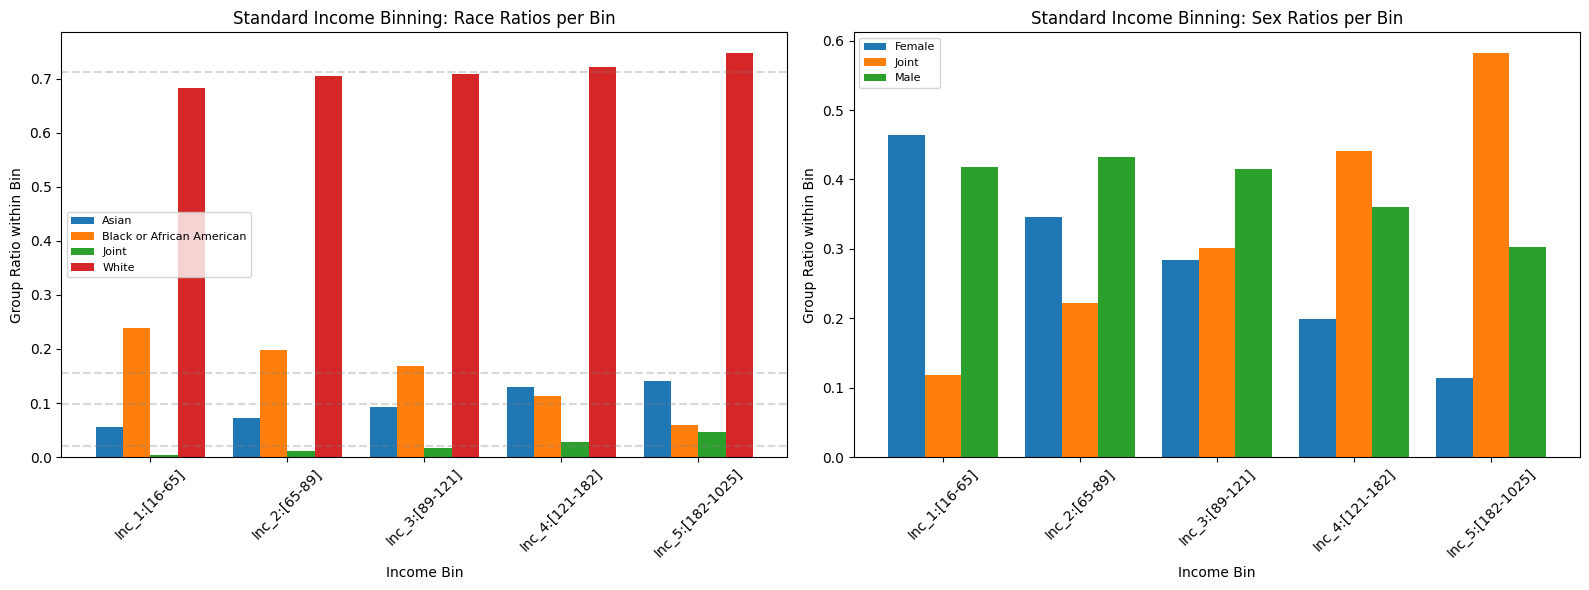

Saved visualization to /content/drive/MyDrive/CS483_FairLend/standard_binning_bias.png


In [ ]:
# Visualization: Group ratios across income bins
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Race distribution across income bins
major_races = ['White', 'Black or African American', 'Asian', 'Joint']
pivot_race = income_race_table[income_race_table['group'].isin(major_races)].pivot(
    index='bin', columns='group', values='bin_ratio'
)
pivot_race.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Standard Income Binning: Race Ratios per Bin')
axes[0].set_ylabel('Group Ratio within Bin')
axes[0].set_xlabel('Income Bin')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)

# Add overall ratio lines
overall_ratios = pdf['derived_race'].value_counts(normalize=True)
for race in major_races:
    if race in overall_ratios:
        axes[0].axhline(y=overall_ratios[race], color='gray', linestyle='--', alpha=0.3)

# Plot 2: Sex distribution across income bins
pivot_sex = income_sex_table.pivot(
    index='bin', columns='group', values='bin_ratio'
)
pivot_sex.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Standard Income Binning: Sex Ratios per Bin')
axes[1].set_ylabel('Group Ratio within Bin')
axes[1].set_xlabel('Income Bin')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/standard_binning_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved visualization to {PROJECT_DIR}/standard_binning_bias.png')

## 4. ε-Biased Fair Binning

We implement the ε-biased binning approach inspired by Asudeh et al. This is a simplified version using the Divide-and-Conquer (D&C) algorithm (Algorithm 5 from the paper), which finds a near-optimal ε-biased binning in near-linear time.

The key idea: starting from equal-frequency boundaries, we shift boundaries slightly to ensure that each bin's group ratio stays within ε of the overall group ratio.

In [ ]:
def epsilon_biased_binning(values, groups, k, epsilon, attr_name='attr'):
    """
    ε-biased binning using the D&C approach (Algorithm 5 from Asudeh et al.).

    Given sorted attribute values and group labels, find k bin boundaries such that each bin's group ratios deviate from the overall ratios by at most epsilon.

    Parameters:
        values: array of attribute values (will be sorted internally)
        groups: array of group labels corresponding to values
        k: number of bins
        epsilon: maximum allowed bias per bin per group
        attr_name: name prefix for bin labels

    Returns:
        bin_assignments: array of bin labels
        boundaries: array of boundary values
        feasible: bool, whether a valid binning was found
    """
    n = len(values)

    # Sort by attribute value
    sort_idx = np.argsort(values)
    sorted_vals = values[sort_idx]
    sorted_groups = groups[sort_idx]

    # Compute prefix counts for each group
    unique_groups = np.unique(sorted_groups)
    overall_ratios = {}
    for g in unique_groups:
        overall_ratios[g] = np.sum(sorted_groups == g) / n

    # Build prefix count array: cnt[i, g] = # of group g in sorted_groups[0:i]
    group_to_idx = {g: idx for idx, g in enumerate(unique_groups)}
    cnt = np.zeros((n + 1, len(unique_groups)), dtype=np.int64)
    for i in range(n):
        cnt[i + 1] = cnt[i].copy()
        cnt[i + 1, group_to_idx[sorted_groups[i]]] += 1

    def is_epsilon_biased(lo, hi):
        """
        Check if the segment [lo, hi) is ε-biased.
        """
        seg_size = hi - lo
        if seg_size <= 0:
            return False
        for g in unique_groups:
            g_idx = group_to_idx[g]
            seg_count = cnt[hi, g_idx] - cnt[lo, g_idx]
            seg_ratio = seg_count / seg_size
            if abs(seg_ratio - overall_ratios[g]) > epsilon:
                return False
        return True

    def dnc(lo, hi, kappa):
        """
        D&C algorithm (Algorithm 5): recursively partition [lo, hi) into kappa bins.
        Returns list of boundary indices, or None if infeasible.
        """
        if kappa == 1:
            # Base case: the entire segment is one bin
            if is_epsilon_biased(lo, hi):
                return []
            else:
                return None

        # Start at the midpoint boundary of equal-size kappa-binning
        half = int(np.ceil(kappa / 2))
        seg_size = hi - lo
        mid = lo + int(np.ceil(half * seg_size / kappa))

        # Search around mid for a valid split
        max_shift = min(mid - lo, hi - mid) - 1
        found = False
        best_mid = mid

        if is_epsilon_biased(lo, mid) and is_epsilon_biased(mid, hi):
            found = True
            best_mid = mid
        else:
            for j in range(1, max_shift + 1):
                if mid + j < hi and is_epsilon_biased(lo, mid + j) and is_epsilon_biased(mid + j, hi):
                    best_mid = mid + j
                    found = True
                    break
                if mid - j > lo and is_epsilon_biased(lo, mid - j) and is_epsilon_biased(mid - j, hi):
                    best_mid = mid - j
                    found = True
                    break

        if not found:
            return None

        # Recurse on both halves
        left_bounds = dnc(lo, best_mid, half)
        right_bounds = dnc(best_mid, hi, kappa - half)

        if left_bounds is None or right_bounds is None:
            return None

        return left_bounds + [best_mid] + right_bounds

    # Run D&C
    boundary_indices = dnc(0, n, k)

    if boundary_indices is None:
        print(f'WARNING: No feasible ε-biased binning found for ε={epsilon}, k={k}')
        return None, None, False

    # Convert boundary indices to boundary values
    boundary_indices = sorted(boundary_indices)
    boundaries = [sorted_vals[0]]  # lower bound
    for bi in boundary_indices:
        # Boundary is between sorted_vals[bi-1] and sorted_vals[bi]
        boundaries.append((sorted_vals[bi - 1] + sorted_vals[bi]) / 2.0)
    boundaries.append(sorted_vals[-1])  # upper bound
    boundaries = np.array(boundaries)

    # Assign bins to the ORIGINAL (unsorted) data
    bin_assignments_sorted = np.zeros(n, dtype=int)
    all_bounds = [0] + boundary_indices + [n]
    for b in range(k):
        lo_idx = all_bounds[b]
        hi_idx = all_bounds[b + 1]
        bin_assignments_sorted[lo_idx:hi_idx] = b

    # Map back to original order
    bin_assignments = np.zeros(n, dtype=int)
    bin_assignments[sort_idx] = bin_assignments_sorted

    # Create labels
    labels = []
    for i in range(k):
        lo_val = boundaries[i]
        hi_val = boundaries[i + 1]
        labels.append(f'{attr_name}_{i+1}:[{lo_val:.0f}-{hi_val:.0f}]')

    named_assignments = np.array([labels[b] for b in bin_assignments])

    return named_assignments, boundaries, True

In [ ]:
# Apply ε-biased binning to income with respect to race
EPSILON = 0.03  # 3% max bias threshold (same as paper experiments)

income_vals = pdf['income'].values
race_vals = pdf['derived_race'].values

fair_income_labels, fair_income_bounds, income_feasible = epsilon_biased_binning(
    income_vals, race_vals, K_BINS, EPSILON, attr_name='FairInc'
)

if income_feasible:
    pdf['income_bin_fair'] = fair_income_labels
    print(f'ε-biased Income Binning (ε={EPSILON}) - SUCCESS')
    print(f'Boundaries: {fair_income_bounds}')
    print()
    print('Fair Income bin distribution:')
    print(pd.Series(fair_income_labels).value_counts().sort_index())
else:
    print('Trying with larger epsilon...')
    for eps in [0.04, 0.05, 0.06, 0.08, 0.10]:
        fair_income_labels, fair_income_bounds, income_feasible = epsilon_biased_binning(
            income_vals, race_vals, K_BINS, eps, attr_name='FairInc'
        )
        if income_feasible:
            pdf['income_bin_fair'] = fair_income_labels
            EPSILON_INCOME = eps
            print(f'ε-biased Income Binning (ε={eps}) - SUCCESS')
            print(f'Boundaries: {fair_income_bounds}')
            break

Trying with larger epsilon...
ε-biased Income Binning (ε=0.08) - SUCCESS
Boundaries: [  16.   69.   89.  121.  140. 1025.]


In [ ]:
# Apply ε-biased binning to loan amount with respect to race
loan_vals = pdf['loan_amount'].values

fair_loan_labels, fair_loan_bounds, loan_feasible = epsilon_biased_binning(
    loan_vals, race_vals, K_BINS, EPSILON, attr_name='FairLoan'
)

if loan_feasible:
    pdf['loan_amount_bin_fair'] = fair_loan_labels
    print(f'ε-biased Loan Amount Binning (ε={EPSILON}) - SUCCESS')
    print(f'Boundaries: {fair_loan_bounds}')
    print()
    print('Fair Loan Amount bin distribution:')
    print(pd.Series(fair_loan_labels).value_counts().sort_index())
else:
    print('Trying with larger epsilon...')
    for eps in [0.04, 0.05, 0.06, 0.08, 0.10]:
        fair_loan_labels, fair_loan_bounds, loan_feasible = epsilon_biased_binning(
            loan_vals, race_vals, K_BINS, eps, attr_name='FairLoan'
        )
        if loan_feasible:
            pdf['loan_amount_bin_fair'] = fair_loan_labels
            EPSILON_LOAN = eps
            print(f'ε-biased Loan Amount Binning (ε={eps}) - SUCCESS')
            print(f'Boundaries: {fair_loan_bounds}')
            break

Trying with larger epsilon...
ε-biased Loan Amount Binning (ε=0.06) - SUCCESS
Boundaries: [5.000e+03 7.500e+04 1.650e+05 2.450e+05 2.850e+05 5.105e+06]


### 4.1 Compare Bias: Standard vs Fair Binning

In [ ]:
# Bias comparison
results = []

# Standard binning bias
std_inc_race_bias, _ = compute_binning_bias(pdf, 'income_bin_std', 'derived_race')
std_inc_sex_bias, _ = compute_binning_bias(pdf, 'income_bin_std', 'derived_sex')
std_loan_race_bias, _ = compute_binning_bias(pdf, 'loan_amount_bin_std', 'derived_race')

results.append({'Method': 'Standard', 'Attribute': 'Income', 'Group': 'Race', 'Max Bias': std_inc_race_bias})
results.append({'Method': 'Standard', 'Attribute': 'Income', 'Group': 'Sex', 'Max Bias': std_inc_sex_bias})
results.append({'Method': 'Standard', 'Attribute': 'Loan Amount', 'Group': 'Race', 'Max Bias': std_loan_race_bias})

# Fair binning bias
if 'income_bin_fair' in pdf.columns:
    fair_inc_race_bias, _ = compute_binning_bias(pdf, 'income_bin_fair', 'derived_race')
    fair_inc_sex_bias, _ = compute_binning_bias(pdf, 'income_bin_fair', 'derived_sex')
    results.append({'Method': 'ε-biased', 'Attribute': 'Income', 'Group': 'Race', 'Max Bias': fair_inc_race_bias})
    results.append({'Method': 'ε-biased', 'Attribute': 'Income', 'Group': 'Sex', 'Max Bias': fair_inc_sex_bias})

if 'loan_amount_bin_fair' in pdf.columns:
    fair_loan_race_bias, _ = compute_binning_bias(pdf, 'loan_amount_bin_fair', 'derived_race')
    results.append({'Method': 'ε-biased', 'Attribute': 'Loan Amount', 'Group': 'Race', 'Max Bias': fair_loan_race_bias})

comparison_df = pd.DataFrame(results)
comparison_df['Max Bias (%)'] = (comparison_df['Max Bias'] * 100).round(2)
print('=== Bias Comparison: Standard vs ε-Biased Binning ===')
print(comparison_df.to_string(index=False))

=== Bias Comparison: Standard vs ε-Biased Binning ===
  Method   Attribute Group  Max Bias  Max Bias (%)
Standard      Income  Race    0.0963          9.63
Standard      Income   Sex    0.2514         25.14
Standard Loan Amount  Race    0.0765          7.65
ε-biased      Income  Race    0.0800          8.00
ε-biased      Income   Sex    0.2108         21.08
ε-biased Loan Amount  Race    0.0600          6.00


### 4.2 Compute Price of Fairness (PoF)

In [ ]:
def compute_pof(df, bin_col, n):
    """
    Compute Price of Fairness (Equation 7 from paper).
    PoF = average over bins of |1 - k*|B_j| / n|
    """
    bin_sizes = df[bin_col].value_counts()
    k = len(bin_sizes)
    expected_size = n / k

    pof_values = [abs(1 - (size / expected_size)) for size in bin_sizes]
    return np.mean(pof_values)

n_total = len(pdf)

pof_results = []
pof_results.append({
    'Method': 'Standard', 'Attribute': 'Income',
    'PoF': compute_pof(pdf, 'income_bin_std', n_total)
})
pof_results.append({
    'Method': 'Standard', 'Attribute': 'Loan Amount',
    'PoF': compute_pof(pdf, 'loan_amount_bin_std', n_total)
})

if 'income_bin_fair' in pdf.columns:
    pof_results.append({
        'Method': 'ε-biased', 'Attribute': 'Income',
        'PoF': compute_pof(pdf, 'income_bin_fair', n_total)
    })

if 'loan_amount_bin_fair' in pdf.columns:
    pof_results.append({
        'Method': 'ε-biased', 'Attribute': 'Loan Amount',
        'PoF': compute_pof(pdf, 'loan_amount_bin_fair', n_total)
    })

pof_df = pd.DataFrame(pof_results)
pof_df['PoF (%)'] = (pof_df['PoF'] * 100).round(2)
print('=== Price of Fairness ===')
print(pof_df.to_string(index=False))
print()
print('PoF close to 0% means the fair binning barely deviates from equal-frequency.')

=== Price of Fairness ===
  Method   Attribute      PoF  PoF (%)
Standard      Income 0.014778     1.48
Standard Loan Amount 0.042821     4.28
ε-biased      Income 0.294307    29.43
ε-biased Loan Amount 0.235359    23.54

PoF close to 0% means the fair binning barely deviates from equal-frequency.


### 4.3 Visualization: Standard vs Fair Binning

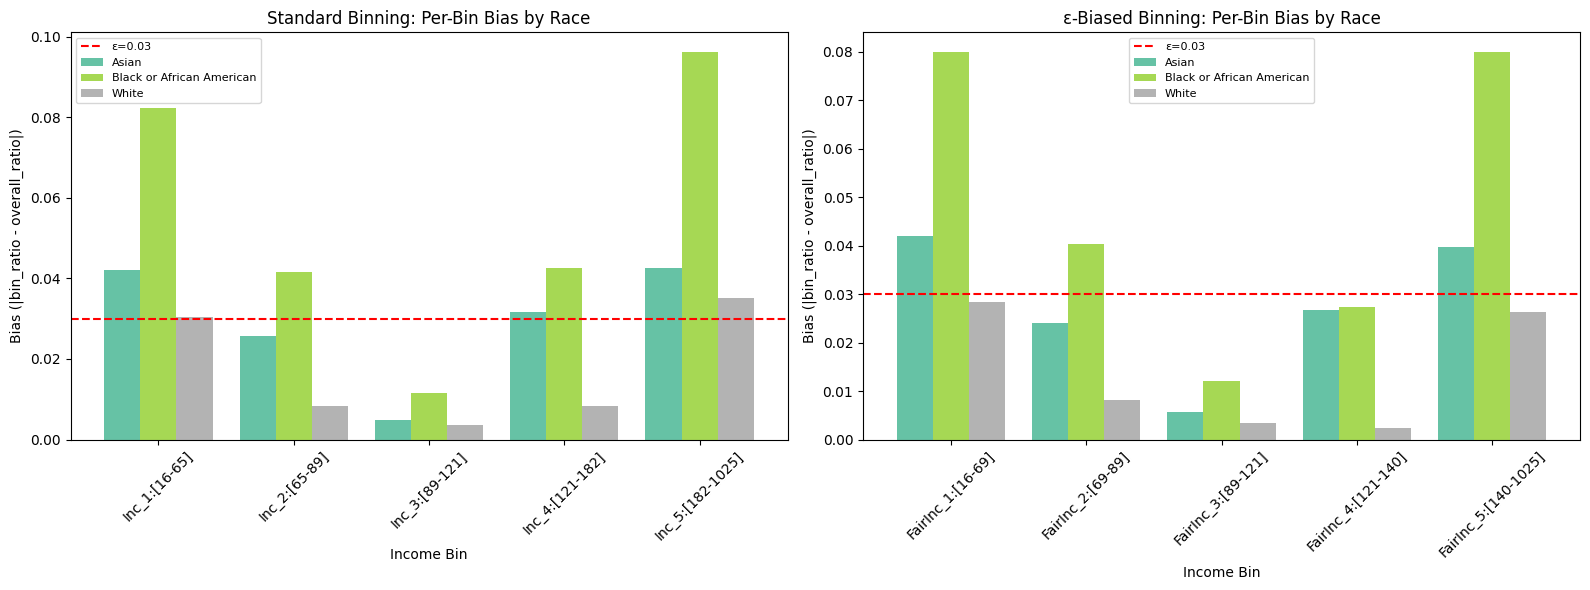

Saved comparison to /content/drive/MyDrive/CS483_FairLend/binning_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

major_races = ['White', 'Black or African American', 'Asian']

# Standard binning bias by race for income
_, std_table = compute_binning_bias(pdf, 'income_bin_std', 'derived_race')
std_pivot = std_table[std_table['group'].isin(major_races)].pivot(
    index='bin', columns='group', values='bias'
)
std_pivot.plot(kind='bar', ax=axes[0], width=0.8, colormap='Set2')
axes[0].set_title('Standard Binning: Per-Bin Bias by Race')
axes[0].set_ylabel('Bias (|bin_ratio - overall_ratio|)')
axes[0].set_xlabel('Income Bin')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=EPSILON, color='red', linestyle='--', label=f'ε={EPSILON}')
axes[0].legend(fontsize=8)

# Fair binning bias by race for income
if 'income_bin_fair' in pdf.columns:
    _, fair_table = compute_binning_bias(pdf, 'income_bin_fair', 'derived_race')
    fair_pivot = fair_table[fair_table['group'].isin(major_races)].pivot(
        index='bin', columns='group', values='bias'
    )
    fair_pivot.plot(kind='bar', ax=axes[1], width=0.8, colormap='Set2')
    axes[1].set_title('ε-Biased Binning: Per-Bin Bias by Race')
    axes[1].set_ylabel('Bias (|bin_ratio - overall_ratio|)')
    axes[1].set_xlabel('Income Bin')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(y=EPSILON, color='red', linestyle='--', label=f'ε={EPSILON}')
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/binning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved comparison to {PROJECT_DIR}/binning_comparison.png')

## 5. Prepare Transactional Features for Association Rule Mining

For Member B's FP-Growth analysis, we create a fully discretized transactional dataset where each row is a "transaction" of binned features.

In [ ]:
# Create transactional columns
trans_df = pdf.copy()

# Map action_taken to readable labels
trans_df['outcome'] = trans_df['denied'].map({0: 'originated', 1: 'denied'})

# Bin applicant age (already comes as ranges in HMDA 2023)
print('Age distribution:')
print(trans_df['applicant_age'].value_counts())

# Map loan type
loan_type_map = {1: 'Conventional', 2: 'FHA', 3: 'VA', 4: 'USDA'}
trans_df['loan_type_label'] = trans_df['loan_type'].map(loan_type_map).fillna('Other')

# Map loan purpose
loan_purpose_map = {1: 'Purchase', 2: 'Improvement', 31: 'Refinancing', 32: 'CashOutRefi', 4: 'Other', 5: 'NotApplicable'}
trans_df['loan_purpose_label'] = trans_df['loan_purpose'].map(loan_purpose_map).fillna('Other')

# Map occupancy type
occ_map = {1: 'PrimaryRes', 2: 'SecondRes', 3: 'Investment'}
trans_df['occupancy_label'] = trans_df['occupancy_type'].map(occ_map).fillna('Other')

# Dwelling category (already a readable string from HMDA)
trans_df['dwelling_label'] = trans_df['derived_dwelling_category'].fillna('Unknown')

print('\nLoan type distribution:')
print(trans_df['loan_type_label'].value_counts())

print('\nLoan purpose distribution:')
print(trans_df['loan_purpose_label'].value_counts())

print('\nDwelling category distribution:')
print(trans_df['dwelling_label'].value_counts())

Age distribution:
applicant_age
35-44    27058
25-34    24993
45-54    21268
55-64    15159
65-74     8288
>74       3469
<25       3244
8888         2
Name: count, dtype: int64

Loan type distribution:
loan_type_label
Conventional    87837
FHA             13195
VA               2420
USDA               29
Name: count, dtype: int64

Loan purpose distribution:
loan_purpose_label
Purchase         62066
Improvement      12452
Other            12416
CashOutRefi      10453
Refinancing       6092
NotApplicable        2
Name: count, dtype: int64

Dwelling category distribution:
dwelling_label
Single Family (1-4 Units):Site-Built      102964
Single Family (1-4 Units):Manufactured       511
Multifamily:Site-Built                         6
Name: count, dtype: int64


In [ ]:
# DTI binning (already comes as ranges, simplify to broader categories)
def simplify_dti(dti):
    if pd.isna(dti) or dti in ['NA', 'Exempt']:
        return 'DTI_Unknown'
    if dti == '<20%':
        return 'DTI_Low'
    if dti in ['20%-<30%', '30%-<36%']:
        return 'DTI_Medium'
    if dti in ['50%-60%', '>60%']:
        return 'DTI_High'
    # Individual values 36-49
    try:
        val = float(dti)
        if val < 43:
            return 'DTI_Medium'
        else:
            return 'DTI_MedHigh'
    except:
        return 'DTI_Unknown'

trans_df['dti_bin'] = trans_df['debt_to_income_ratio'].apply(simplify_dti)

print('Simplified DTI distribution:')
print(trans_df['dti_bin'].value_counts())

Simplified DTI distribution:
dti_bin
DTI_Medium     52434
DTI_MedHigh    27408
DTI_High       16485
DTI_Low         4258
DTI_Unknown     2896
Name: count, dtype: int64


## 6. Export to Google Drive

We save three datasets:
1. **Cleaned dataset** (full, with all numeric and categorical columns) as Parquet
2. **Standard-binned transactional dataset** for FP-Growth with standard binning
3. **Fair-binned transactional dataset** for FP-Growth with ε-biased binning

In [ ]:
# 1. Full cleaned dataset (for clustering - Member C)
clean_export_cols = [
    'action_taken', 'denied',
    'derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age',
    'income', 'loan_amount', 'interest_rate',
    'combined_loan_to_value_ratio', 'loan_term',
    'dti_numeric',
    'loan_type', 'loan_purpose', 'occupancy_type', 'lien_status',
    'derived_dwelling_category',
    'county_code', 'census_tract',
]

# Only include columns that exist
clean_export_cols = [c for c in clean_export_cols if c in trans_df.columns]

clean_path = f'{PROJECT_DIR}/hmda_chicago_2023_cleaned.parquet'
trans_df[clean_export_cols].to_parquet(clean_path, index=False)
print(f'Saved cleaned dataset: {clean_path}')
print(f'  Shape: {trans_df[clean_export_cols].shape}')
print(f'  Size: {os.path.getsize(clean_path) / (1024**2):.1f} MB')

Saved cleaned dataset: /content/drive/MyDrive/CS483_FairLend/hmda_chicago_2023_cleaned.parquet
  Shape: (103481, 19)
  Size: 1.1 MB


In [ ]:
# 2. Standard-binned transactional dataset (for FP-Growth - Member B)
trans_std_cols = [
    'outcome',
    'derived_race', 'derived_sex', 'derived_ethnicity',
    'applicant_age',
    'income_bin_std', 'loan_amount_bin_std',
    'dti_bin',
    'loan_type_label', 'loan_purpose_label', 'occupancy_label',
]

trans_std_cols = [c for c in trans_std_cols if c in trans_df.columns]

std_path = f'{PROJECT_DIR}/hmda_chicago_2023_standard_binned.parquet'
trans_df[trans_std_cols].to_parquet(std_path, index=False)
print(f'Saved standard-binned dataset: {std_path}')
print(f'  Shape: {trans_df[trans_std_cols].shape}')
print(f'  Size: {os.path.getsize(std_path) / (1024**2):.1f} MB')

Saved standard-binned dataset: /content/drive/MyDrive/CS483_FairLend/hmda_chicago_2023_standard_binned.parquet
  Shape: (103481, 11)
  Size: 0.3 MB


In [ ]:
# 3. Fair-binned transactional dataset (for FP-Growth comparison - Member B)
trans_fair_cols = [
    'outcome',
    'derived_race', 'derived_sex', 'derived_ethnicity',
    'applicant_age',
    'dti_bin',
    'loan_type_label', 'loan_purpose_label', 'occupancy_label',
]

# Add fair bin columns if they exist
if 'income_bin_fair' in trans_df.columns:
    trans_fair_cols.append('income_bin_fair')
if 'loan_amount_bin_fair' in trans_df.columns:
    trans_fair_cols.append('loan_amount_bin_fair')

trans_fair_cols = [c for c in trans_fair_cols if c in trans_df.columns]

fair_path = f'{PROJECT_DIR}/hmda_chicago_2023_fair_binned.parquet'
trans_df[trans_fair_cols].to_parquet(fair_path, index=False)
print(f'Saved fair-binned dataset: {fair_path}')
print(f'  Shape: {trans_df[trans_fair_cols].shape}')
print(f'  Size: {os.path.getsize(fair_path) / (1024**2):.1f} MB')

Saved fair-binned dataset: /content/drive/MyDrive/CS483_FairLend/hmda_chicago_2023_fair_binned.parquet
  Shape: (103481, 11)
  Size: 0.3 MB


In [ ]:
# 4. Save metadata / summary
metadata = {
    'source': 'HMDA 2023 Snapshot National Loan-Level Dataset',
    'msa': 'Chicago-Naperville-Elgin (16984)',
    'total_rows': len(trans_df),
    'k_bins': K_BINS,
    'epsilon': EPSILON,
    'income_bounds_std': income_bounds.tolist(),
    'loan_bounds_std': loan_bounds.tolist(),
    'income_bounds_fair': fair_income_bounds.tolist() if income_feasible else None,
    'loan_bounds_fair': fair_loan_bounds.tolist() if loan_feasible else None,
    'denial_rate': float(trans_df['denied'].mean()),
    'columns_clean': clean_export_cols,
    'columns_std_binned': trans_std_cols,
    'columns_fair_binned': trans_fair_cols,
}

import json
meta_path = f'{PROJECT_DIR}/pipeline_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Saved metadata: {meta_path}')

Saved metadata: /content/drive/MyDrive/CS483_FairLend/pipeline_metadata.json


In [ ]:
# Final summary
print('=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)
print(f'\nDataset: HMDA 2023 | MSA: Chicago (16980)')
print(f'Total cleaned rows: {len(trans_df):,}')
print(f'Denial rate: {trans_df["denied"].mean()*100:.2f}%')
print(f'\nBinning parameters: k={K_BINS}, ε={EPSILON}')
print(f'Standard income binning race bias: {std_inc_race_bias:.4f} ({std_inc_race_bias*100:.2f}%)')
if 'income_bin_fair' in pdf.columns:
    print(f'Fair income binning race bias: {fair_inc_race_bias:.4f} ({fair_inc_race_bias*100:.2f}%)')
print(f'\nFiles saved to Google Drive at: {PROJECT_DIR}/')
print(f'  1. hmda_chicago_2023_cleaned.parquet (for clustering)')
print(f'  2. hmda_chicago_2023_standard_binned.parquet (for FP-Growth, standard)')
print(f'  3. hmda_chicago_2023_fair_binned.parquet (for FP-Growth, fair)')
print(f'  4. pipeline_metadata.json (bin boundaries and config)')
print(f'  5. standard_binning_bias.png (visualization)')
print(f'  6. binning_comparison.png (visualization)')

PIPELINE COMPLETE

Dataset: HMDA 2023 | MSA: Chicago (16980)
Total cleaned rows: 103,481
Denial rate: 23.89%

Binning parameters: k=5, ε=0.03
Standard income binning race bias: 0.0963 (9.63%)
Fair income binning race bias: 0.0800 (8.00%)

Files saved to Google Drive at: /content/drive/MyDrive/CS483_FairLend/
  1. hmda_chicago_2023_cleaned.parquet (for clustering)
  2. hmda_chicago_2023_standard_binned.parquet (for FP-Growth, standard)
  3. hmda_chicago_2023_fair_binned.parquet (for FP-Growth, fair)
  4. pipeline_metadata.json (bin boundaries and config)
  5. standard_binning_bias.png (visualization)
  6. binning_comparison.png (visualization)


In [ ]:
# Stop Spark
spark.stop()
print('Spark session stopped.')

Spark session stopped.
